    CustKey    DateKey  Discount Amount Invoice Date  Invoice Number  \
0  10000481 2017-04-30          -237.91   2017-04-30          100012   
1  10002220 2017-07-14           368.79   2017-07-14          100233   
2  10002220 2017-10-17           109.73   2017-10-17          116165   
3  10002489 2017-06-03          -211.75   2017-06-03          100096   
4  10004516 2017-05-27         96627.94   2017-05-27          103341   

  Item Class Item Number                             Item  Line Number  \
0        NaN         NaN                 Urban Large Eggs         2000   
1        P01       20910               Moms Sliced Turkey         1000   
2        P01       38076  Cutting Edge Foot-Long Hot Dogs         1000   
3        NaN         NaN                         Kiwi Lox         1000   
4        P01       60776             High Top Sweet Onion         1000   

   List Price  Order Number Promised Delivery Date  Sales Amount  \
0        0.00        200015             2017-04-30    

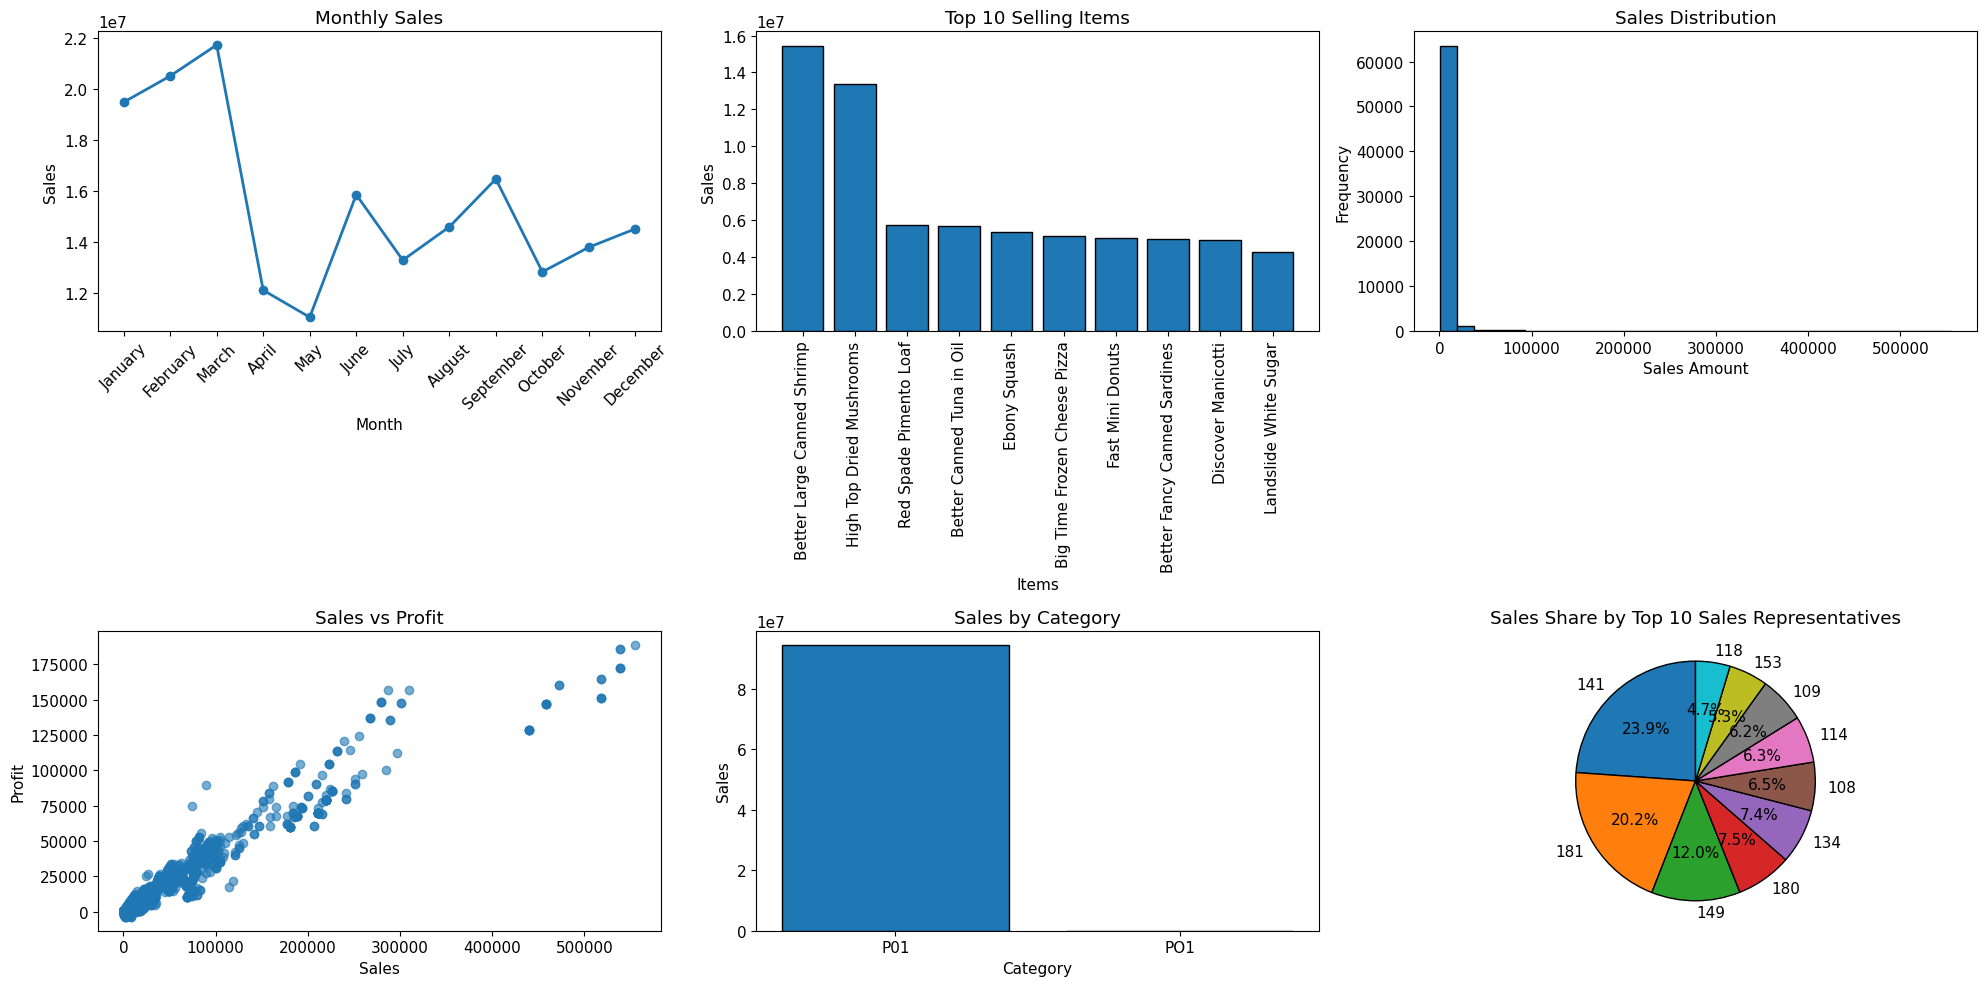

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load Dataset

df = pd.read_excel("/content/SALESDATA.xls")

# data information
print(df.head())
print(df.tail())
print(df.info())
print(df.describe())

print("rows & columns :", df.shape)
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])


print(df.columns)

# for missing values
print(df.isnull().sum())

print("Duplicate Rows :", df.duplicated().sum())


# Remove Duplicate Rows
df = df.drop_duplicates()

# Date Conversion

df["Invoice Date"] = pd.to_datetime(df["Invoice Date"])

df["Year"] = df["Invoice Date"].dt.year
df["Month"] = df["Invoice Date"].dt.month_name()
df["Day"] = df["Invoice Date"].dt.day


# Convert to NumPy Arrays

sales = df["Sales Amount"].to_numpy()
profit = df["Sales Margin Amount"].to_numpy()
quantity = df["Sales Quantity"].to_numpy()
discount = df["Discount Amount"].to_numpy()


# Sales Statistics

print("\n--------- SALES ---------")

print("Total Sales :", np.sum(sales))
print("Average Sales :", np.mean(sales))
print("Median Sales :", np.median(sales))
print("Maximum Sales :", np.max(sales))
print("Minimum Sales :", np.min(sales))
print("Standard Deviation :", np.std(sales))
print("Variance :", np.var(sales))

print("25 Percentile :", np.percentile(sales,25))
print("50 Percentile :", np.percentile(sales,50))
print("75 Percentile :", np.percentile(sales,75))


# Profit Statistics

print("\n--------- PROFIT ---------")

print("Total Profit :", np.sum(profit))
print("Average Profit :", np.mean(profit))
print("Maximum Profit :", np.max(profit))
print("Minimum Profit :", np.min(profit))


# Quantity Statistics

print("\n--------- QUANTITY ---------")

print("Total Quantity :", np.sum(quantity))
print("Average Quantity :", np.mean(quantity))
print("Maximum Quantity :", np.max(quantity))


# Discount Statistics

print("\n--------- DISCOUNT ---------")

print("Average Discount :", np.mean(discount))
print("Maximum Discount :", np.max(discount))
print("Minimum Discount :", np.min(discount))


# Outlier Detection (IQR Method)

Q1 = np.percentile(sales,25)
Q3 = np.percentile(sales,75)

IQR = Q3 - Q1

Lower = Q1 - 1.5 * IQR
Upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Sales Amount"] < Lower) |
    (df["Sales Amount"] > Upper)
]

print("\nNumber of Outliers :", len(outliers))


# Correlation Matrix

numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

print("\nCorrelation Matrix")
print(corr)


# VISUALIZATION


fig = plt.figure(figsize=(20,10))

# Month Order
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

# Monthly Sales
monthly_sales = (
    df.groupby("Month")["Sales Amount"]
      .sum()
      .reindex(month_order)
      .fillna(0)
)

# Top 10 Items
top_items = (
    df.groupby("Item")["Sales Amount"]
      .sum()
      .sort_values(ascending=False) # work as a descending order
      .head(10)
)

# Category Sales
category_sales = (
    df.groupby("Item Class")["Sales Amount"]
      .sum()
)

# ---------------- Graph 1 ----------------
plt.subplot(2,3,1)

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)

# ---------------- Graph 2 ----------------
plt.subplot(2,3,2)

plt.bar(
    top_items.index.astype(str),
    top_items.values,
    edgecolor="black"
)

plt.title("Top 10 Selling Items")
plt.xlabel("Items")
plt.ylabel("Sales")
plt.xticks(rotation=90)

# ---------------- Graph 3 ----------------
plt.subplot(2,3,3)

plt.hist(
    df["Sales Amount"],
    bins=30,
    edgecolor="black"
)

plt.title("Sales Distribution")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")

# ---------------- Graph 4 ----------------
plt.subplot(2,3,4)

plt.scatter(
    df["Sales Amount"],
    df["Sales Margin Amount"],
    alpha=0.6
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

# ---------------- Graph 5 ----------------
plt.subplot(2,3,5)

bars = plt.bar(
    category_sales.index.astype(str),
    category_sales.values,
    edgecolor="black"
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")



# ---------------- Graph 6 ----------------

plt.subplot(2,3,6)

sales_rep = (
    df.groupby("Sales Rep")["Sales Amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.pie(
    sales_rep.values,
    labels=sales_rep.index.astype(str),
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor":"black"}
)

plt.title("Sales Share by Top 10 Sales Representatives")
plt.xticks(rotation=20)

plt.tight_layout()

plt.show()